---
title: Pie Charts
type: lesson
publish: true
---

## A Simple Example

Good for things like budgets, diets, etc., where there is a metaphorical pie that is divided into component parts.

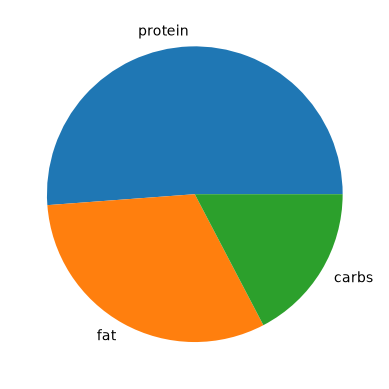

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

my_data = {
    'protein': 65,
    'fat': 40,
    'carbs': 22
}
df = pd.Series(my_data)
df.plot.pie()
plt.show()

## A More Complex Example

In [12]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
print(titanic.columns)
titanic = titanic[['survived','sex','class']]
titanic

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


,survived,sex,class
0,0,male,Third
1,1,female,First
2,1,female,Third
3,1,female,First
4,0,male,Third
...,...,...,...
886,0,male,Second
887,1,female,First
888,0,female,Third
889,1,male,First


## About the data set

The Titanic data set shows the survival rate of passengers on the ill-fated Titanic.

It consists entirely of nominal data for $1316$ passengers.

Each feature stands for a basic demographic attribute with a small domain. 

One column has three unique values, the other three have two. 

These data are ideal for pie charts because: 

1. Each feature contains exhaustive and exclusive labels, meaning every passenger must belong to one and only category from each feature.
2. The number of values per feature is small.

Here we create a pie chart for each feature.

In [13]:
dfs = {}
for col in titanic.columns:
    dfs[col] = titanic.value_counts(col)
titanic_vcs = pd.concat(dfs.values(), keys=dfs.keys(), axis=0)

In [14]:
titanic_vcs.loc['age']

KeyError: 'age'

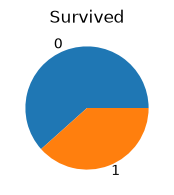

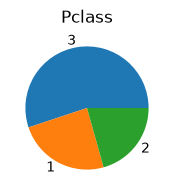

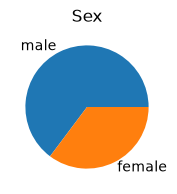

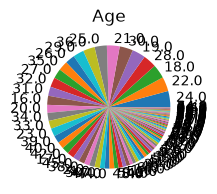

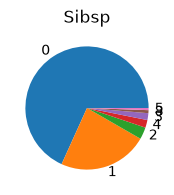

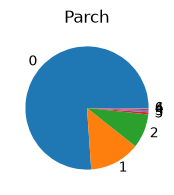

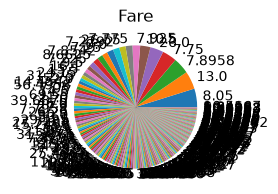

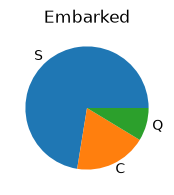

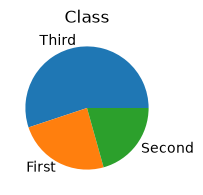

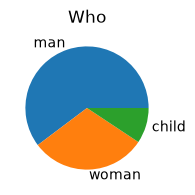

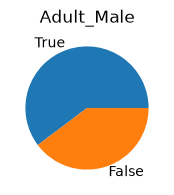

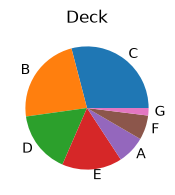

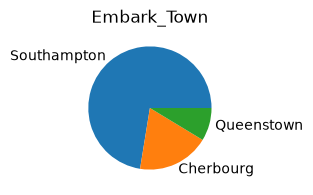

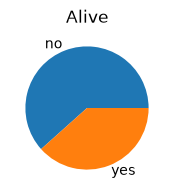

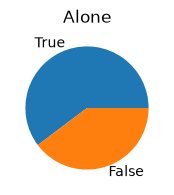

In [10]:
for col in dfs:
    df = dfs[col]
    df.plot.pie(title=col.title(), figsize=(2,2))
    plt.show()

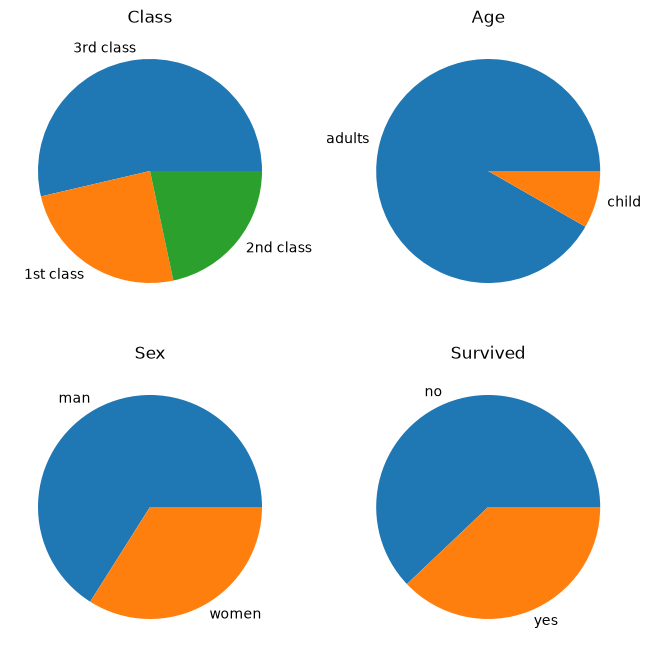

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(8,8))
for i, col in enumerate(titanic.columns):
    c = i % 2
    r = i // 2
    df = titanic.value_counts(col)
    df.plot.pie(title=col.title(), ax=ax[r,c])
plt.show()

## Joint Probabilities

We can see that there are two kinds of features in the Titanic data set: those that define the _category_ of each person and one that defines the _fate_ each person. 

The first set may be thought of as input values and the second as the ouptput.

Let's group the data by the category features and get the value counts of the survival feature. The produces a data frame where the categorical features form the index and the survival feature is projected onto the column axis.

In [8]:
titanic_vc = titanic.value_counts().unstack(fill_value=0)
titanic_vc

survived                yes   no
class     age    sex            
1st class adults man     57  118
                 women  140    4
          child  man      5    0
                 women    1    0
2nd class adults man     14  154
                 women   80   13
          child  man     11    0
                 women   13    0
3rd class adults man     75  387
                 women   76   89
          child  man     13   35
                 women   14   17

In this form, the table tells us, "If a passenger was a first class adult male, what was their chance of surviving?"

We can use the survival rate data to compute a rough probability estimate as follows.

In [9]:
titanic_vc['total'] = titanic_vc['yes'] + titanic_vc['no']
titanic_vc['s_rate'] = round(titanic_vc['yes'] / titanic_vc['total'], 2)
titanic_vc

survived                yes   no  total  s_rate
class     age    sex                           
1st class adults man     57  118    175    0.33
                 women  140    4    144    0.97
          child  man      5    0      5    1.00
                 women    1    0      1    1.00
2nd class adults man     14  154    168    0.08
                 women   80   13     93    0.86
          child  man     11    0     11    1.00
                 women   13    0     13    1.00
3rd class adults man     75  387    462    0.16
                 women   76   89    165    0.46
          child  man     13   35     48    0.27
                 women   14   17     31    0.45

Since these data are exhaustive, exclusive, and relatively few, we can use a pie chart to visualize the probabilities.

:::{note}

Althought the categories are exhaustive and exclusive, the probabilities represented by the pie do not sum to $1$. This is because each value is a joint probability for each combination of categorical features.

:::

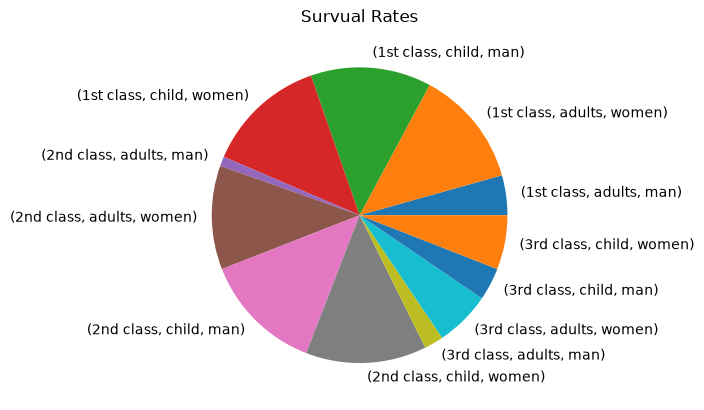

In [10]:
titanic_vc.s_rate.plot.pie(title="Survual Rates")
plt.show()

How readable is this chart? Does it easily show which category combinations had the highest and lowest survival rates? 

It turns out that pie charts become less useful as the number of categories increases.

In such cases, it is often better to fall back onto a bar chart.

The one below clearly shows which categories had the highest and lowest survival rates.

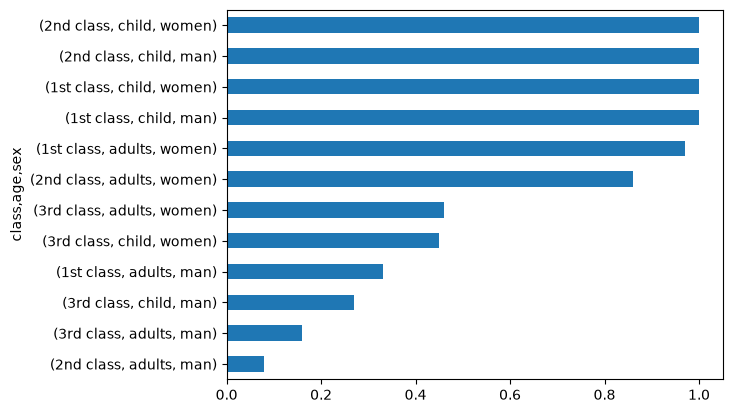

In [11]:
ax = titanic_vc.s_rate.sort_values().plot.barh()
plt.show()

:::{note}

Be careful not to read too much into the survival rates of the first and second class children. Their total numbers are much smaller than the other categories.

Below, we visualize the fate of the adult passengers.

:::

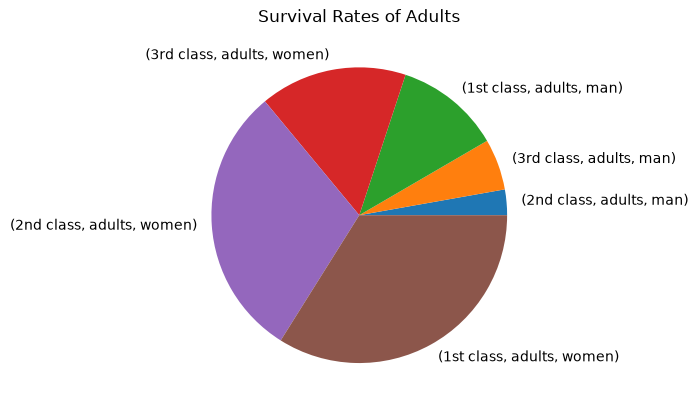

In [15]:
ax = (
    titanic_vc.query("age == 'adults'")
    .s_rate
    .sort_values()
    .plot.pie(title="Survival Rates of Adults")
)
plt.show()

## Arguments

- autopct
- explode
- starting

Using String FormattingYou can pass a standard Python formatting string to autopct to control decimal places.

- `autopct='%1.1f%%'`: Displays one decimal place (e.g., $12.5\%$).
- `autopct='%1.2f%%'`: Displays two decimal places (e.g., $12.50\%$).
- `autopct='%1.0f%%'`: Rounds to the nearest whole integer (e.g., $13\%$)

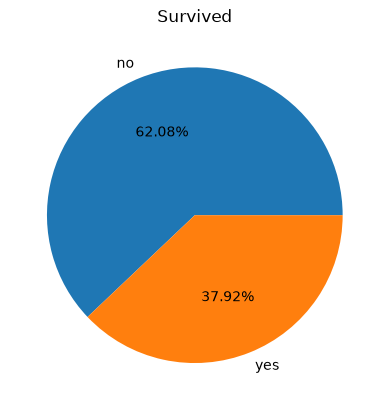

In [ ]:
key_col = 'survived'
dfs[key_col].plot.pie(autopct='%1.2f%%', title=key_col.title())
plt.show()

<Axes: >

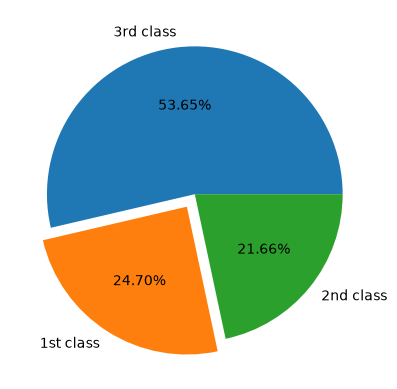

In [ ]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)

<Axes: >

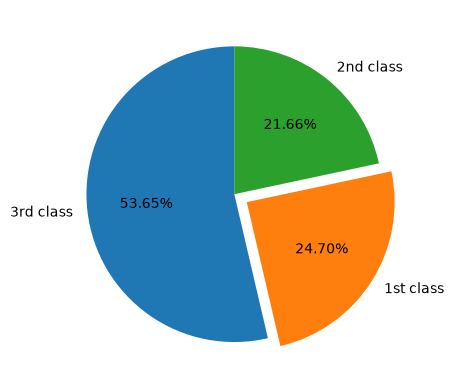

In [ ]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple, startangle=90)

<Axes: >

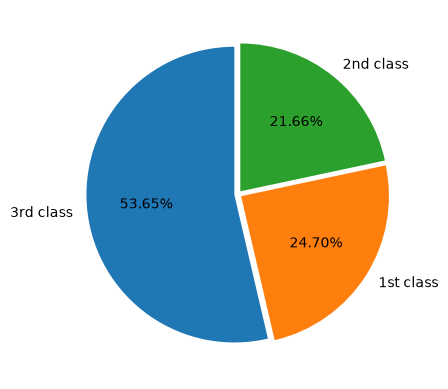

In [ ]:
explode_tuple = [0.025 for i in range(len(dfs['class']))]
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple, startangle=90)